# Primriq Lead Prioritization — EDA & Modeling

This notebook walks through:
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Model training & comparison
5. Predictions on new leads
6. Explainability

All cleaning/feature-engineering logic lives in `src/preprocessing.py` so the notebook
and the production scripts (`src/train.py`, `src/predict.py`, `app.py`) stay in sync.


In [2]:
pip install matplotlib seaborn pandas numpy jupyter scikit-learn

     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     ---------------------------------------- 0.1/8.2 MB 2.0 MB/s eta 0:00:05
     - -------------------------------------- 0.4/8.2 MB 4.9 MB/s eta 0:00:02
     --- ------------------------------------ 0.8/8.2 MB 6.3 MB/s eta 0:00:02
     ---- ----------------------------------- 1.0/8.2 MB 5.7 MB/s eta 0:00:02
     ----- ---------------------------------- 1.1/8.2 MB 5.2 MB/s eta 0:00:02
     ------ --------------------------------- 1.4/8.2 MB 5.0 MB/s eta 0:00:02
     ------- -------------------------------- 1.5/8.2 MB 4.9 MB/s eta 0:00:02
     -------- ------------------------------- 1.7/8.2 MB 4.7 MB/s eta 0:00:02
     --------- ------------------------------ 1.9/8.2 MB 4.6 MB/s eta 0:00:02
     ---------- ----------------------------- 2.1/8.2 MB 4.5 MB/s eta 0:00:02
     ---------- ----------------------------- 2.1/8.2 MB 4.6 MB/s eta 0:00:02
     ---------- ----------------------------- 2.1/8.2 MB 4.6 MB/s eta 0


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(os.path.join(os.getcwd(), 'src'))  # works whether run from notebooks/ or root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)


## 1. Load raw data

In [5]:
hist = pd.read_csv('../data/historical_leads.csv') if os.path.exists('../data/historical_leads.csv') else pd.read_csv('data/historical_leads.csv')
new_leads = pd.read_csv('../data/new_incoming_leads.csv') if os.path.exists('../data/new_incoming_leads.csv') else pd.read_csv('data/new_incoming_leads.csv')

print('Historical leads shape:', hist.shape)
print('New leads shape:', new_leads.shape)
hist.head()


Historical leads shape: (2500, 20)
New leads shape: (200, 17)


,Lead_ID,Submission_Timestamp,Name,Phone,Preferred_Callback_Time,Program_Interested,Highest_Qualification,Current_Status,Experience_Years,City,Lead_Source,Campaign,Device,Graduation_Year,Expected_Salary_LPA,Message,Assigned_Counsellor,Callback_Timestamp,Call_Picked,Call_Response
0,L00001,2026-01-01 17:05,Harsh Saxena,9443043868,Morning,Generative AI,Working Professional,Student,7,Ahmedabad,Google Search,Organic,Mobile,2021,8.0,Need fee details.,Priya,NaN,No,Not Interested
1,L00002,2026-04-19 09:25,Harsh Kumar,8900979098,Morning,Generative AI,NaN,Job Seeker,7,Bengaluru,Referral,Webinar_June,Desktop,2021,NaN,I already know Python and SQL. Looking for job...,Sneha,2026-04-22 12:25,Yes,Needs More Information
2,L00003,2026-05-20 12:35,Neha Singh,9717955856,Evening,Machine Learning,BCA,Job Seeker,10,Kolkata,Google Search,Referral,Desktop,2021,6.0,Brochure only.,Priya,NaN,No,Not Interested
3,L00004,2026-05-23 18:58,Karan Kumar,9135550805,Evening,Business Analytics,Working Professional,Working Professional,0,Kolkata,Referral,GoogleAds,Desktop,2022,5.0,No specific query.,Kunal,NaN,No,Switched Off
4,L00005,2026-01-22 17:50,Vikas Mehta,9796373372,Morning,Machine Learning,B.Tech,Student,10,Noida,Website,GoogleAds,Desktop,2017,3.0,NaN,Priya,NaN,No,No Response After Greeting


## 2. Data Exploration & Cleaning

Key observations from manual inspection of the raw CSV:
- `City` has mixed-case duplicates (e.g. `Noida` vs `NOIDA`) — these need to be normalised.
- `Phone` numbers have inconsistent lengths (some <10 digits) — likely data entry errors.
- `Highest_Qualification` has ~3-4% missing values.
- `Expected_Salary_LPA` has ~9-13% missing values.
- `Message` has ~2-3% missing values (blank enquiries).
- `Callback_Timestamp` is missing for ~36% of rows — this simply means the call was
  never returned, which is expected and informative (not a data quality issue).
- No exact full-row duplicates or duplicate Lead_IDs were found in this dataset, but the
  cleaning pipeline checks for and would remove them if present.

All of this is handled by `clean_dataframe()` in `src/preprocessing.py`. Decisions and
reasoning are documented as comments directly in that file and summarised in
`brief_report.md`.


In [6]:
missing_pct = (hist.isna().mean() * 100).round(1)
print('Missing value % by column (historical_leads.csv):')
print(missing_pct[missing_pct > 0])


Missing value % by column (historical_leads.csv):
Highest_Qualification     3.7
Expected_Salary_LPA      13.1
Message                   2.8
Callback_Timestamp       36.0
dtype: float64


In [7]:
print('Full-row duplicates:', hist.duplicated().sum())
print('Duplicate Lead_IDs:', hist.duplicated(subset=['Lead_ID']).sum())
print()
print('City raw values (note mixed case):', sorted(hist['City'].unique())) 


Full-row duplicates: 0
Duplicate Lead_IDs: 0

City raw values (note mixed case): ['AHMEDABAD', 'Ahmedabad', 'BENGALURU', 'Bengaluru', 'DELHI', 'Delhi', 'HYDERABAD', 'Hyderabad', 'INDORE', 'Indore', 'JAIPUR', 'Jaipur', 'KOLKATA', 'Kolkata', 'LUCKNOW', 'Lucknow', 'NOIDA', 'Noida', 'PUNE', 'Pune']


In [8]:
from preprocessing import run_pipeline

hist_clean, cmap, report = run_pipeline(hist, is_historical=True)
print('Cleaning report:', report)
print('Shape after cleaning + feature engineering:', hist_clean.shape)
hist_clean.head()


Cleaning report: {'duplicates': {'full_row_duplicates_removed': 0, 'duplicate_lead_id_removed': 0}, 'rows_after_cleaning': 2500}
Shape after cleaning + feature engineering: (2500, 43)


,Lead_ID,Submission_Timestamp,Name,Phone,Preferred_Callback_Time,Program_Interested,Highest_Qualification,Current_Status,Experience_Years,City,Lead_Source,Campaign,Device,Graduation_Year,Expected_Salary_LPA,Message,Assigned_Counsellor,Callback_Timestamp,Call_Picked,Call_Response,salary_missing,invalid_phone,message_length,word_count,has_career_switch_keywords,has_urgent_keywords,has_question_mark,message_is_empty,submission_hour,submission_day,submission_month,submission_dayofweek,submission_is_weekend,preferred_callback_part_of_day,preferred_callback_hour,experience_bucket,years_since_graduation,source_quality_score,career_switcher_signal,weekend_x_source_quality,is_repeat_enquirer,target_call_picked,target_meaningful_engagement
0,L00001,2026-01-01 17:05,Harsh Saxena,9443043868,Morning,Generative Ai,Working Professional,Student,7,Ahmedabad,Google Search,Organic,Mobile,2021,8.0,Need fee details.,Priya,NaN,No,Not Interested,0,0,17,3,0,0,0,0,17,1,1,3,0,Morning,9,Senior (6-10y),5,2,0,0,0,0,0
1,L00002,2026-04-19 09:25,Harsh Kumar,8900979098,Morning,Generative Ai,Unknown,Job Seeker,7,Bengaluru,Referral,Webinar_June,Desktop,2021,6.0,I already know Python and SQL. Looking for job...,Sneha,2026-04-22 12:25,Yes,Needs More Information,1,0,58,10,1,0,0,0,9,19,4,6,1,Morning,9,Senior (6-10y),5,3,1,3,0,1,1
2,L00003,2026-05-20 12:35,Neha Singh,9717955856,Evening,Machine Learning,Bca,Job Seeker,10,Kolkata,Google Search,Referral,Desktop,2021,6.0,Brochure only.,Priya,NaN,No,Not Interested,0,0,14,2,0,0,0,0,12,20,5,2,0,Evening,18,Senior (6-10y),5,2,1,0,1,0,0
3,L00004,2026-05-23 18:58,Karan Kumar,9135550805,Evening,Business Analytics,Working Professional,Working Professional,0,Kolkata,Referral,Googleads,Desktop,2022,5.0,No specific query.,Kunal,NaN,No,Switched Off,0,0,18,3,0,0,0,0,18,23,5,5,1,Evening,18,Fresher,4,3,0,3,0,0,0
4,L00005,2026-01-22 17:50,Vikas Mehta,9796373372,Morning,Machine Learning,B.Tech,Student,10,Noida,Website,Googleads,Desktop,2017,3.0,,Priya,NaN,No,No Response After Greeting,0,0,0,0,0,0,0,1,17,22,1,3,0,Morning,9,Senior (6-10y),9,3,0,0,0,0,0


## 3. Exploratory Data Analysis

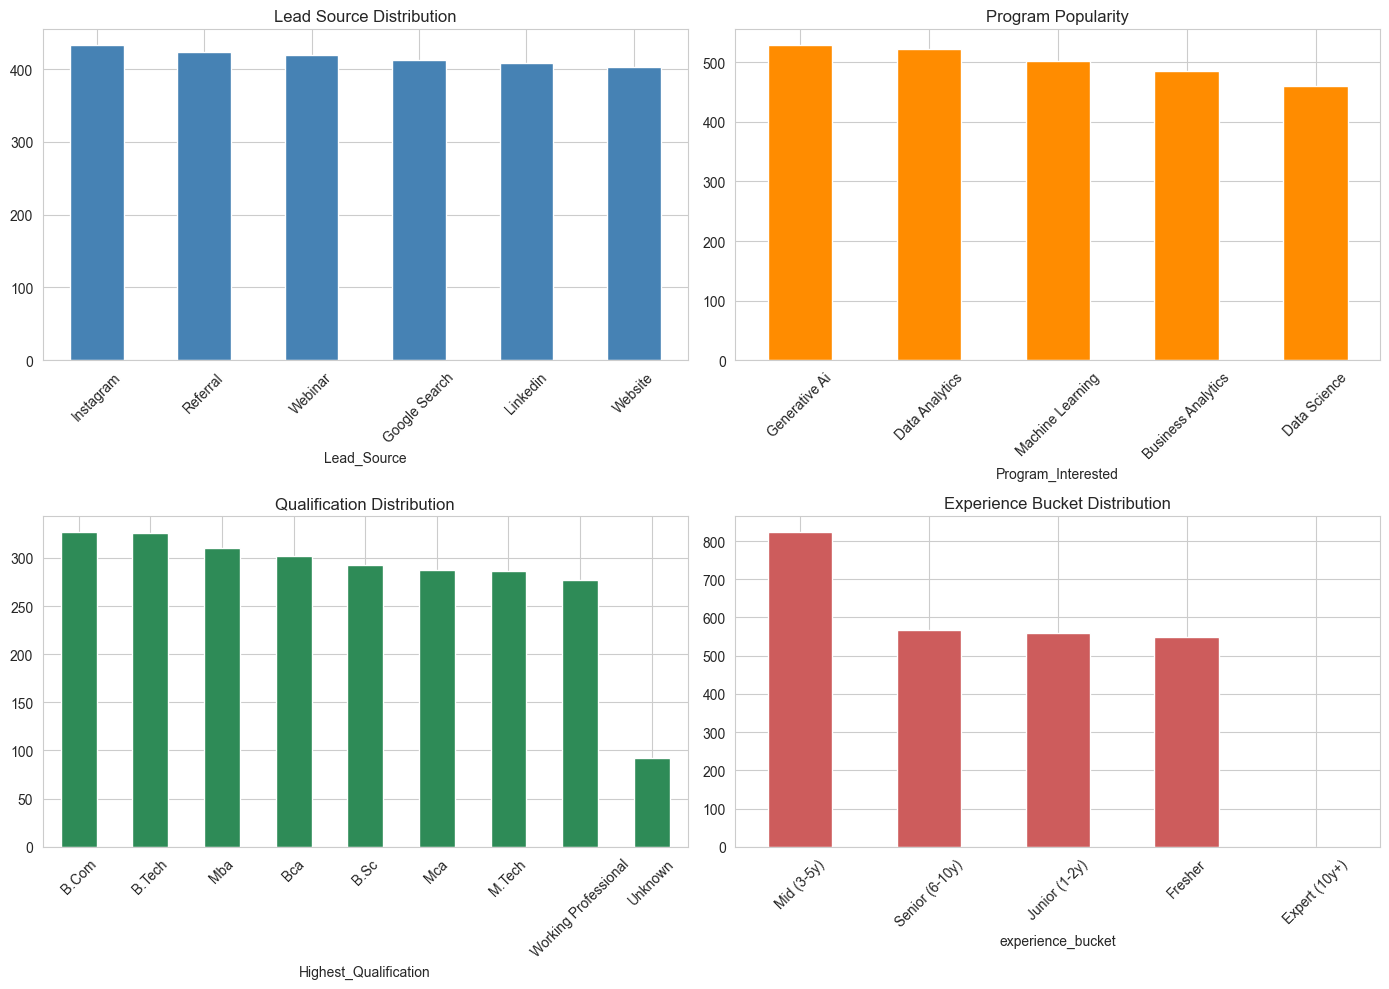

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hist_clean['Lead_Source'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Lead Source Distribution')
axes[0,0].tick_params(axis='x', rotation=45)

hist_clean['Program_Interested'].value_counts().plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Program Popularity')
axes[0,1].tick_params(axis='x', rotation=45)

hist_clean['Highest_Qualification'].value_counts().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Qualification Distribution')
axes[1,0].tick_params(axis='x', rotation=45)

hist_clean['experience_bucket'].value_counts().plot(kind='bar', ax=axes[1,1], color='indianred')
axes[1,1].set_title('Experience Bucket Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


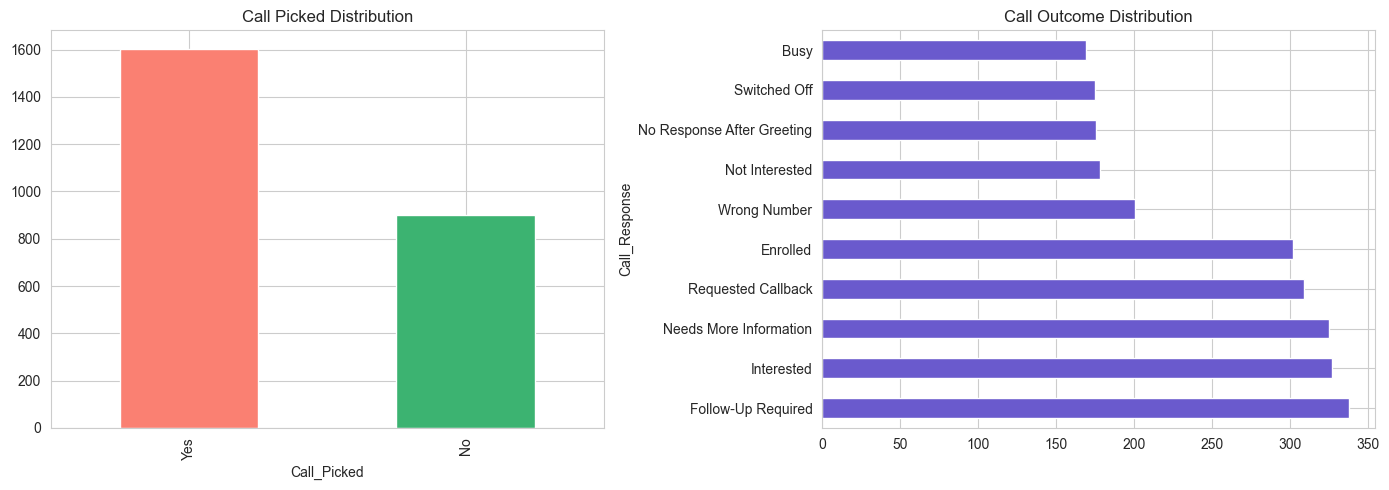

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist_clean['Call_Picked'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon','mediumseagreen'])
axes[0].set_title('Call Picked Distribution')

hist_clean['Call_Response'].value_counts().plot(kind='barh', ax=axes[1], color='slateblue')
axes[1].set_title('Call Outcome Distribution')

plt.tight_layout()
plt.show()


Lead_Source
Webinar          0.671429
Referral         0.669031
Linkedin         0.652812
Instagram        0.628176
Google Search    0.616505
Website          0.602978
Name: target_call_picked, dtype: float64


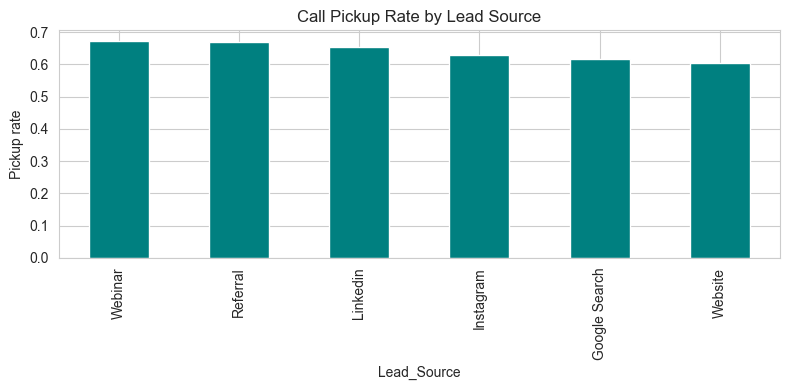

In [11]:
# Call-pickup rate by lead source
pickup_by_source = hist_clean.groupby('Lead_Source')['target_call_picked'].mean().sort_values(ascending=False)
print(pickup_by_source)

pickup_by_source.plot(kind='bar', figsize=(8,4), color='teal', title='Call Pickup Rate by Lead Source')
plt.ylabel('Pickup rate')
plt.tight_layout()
plt.show()


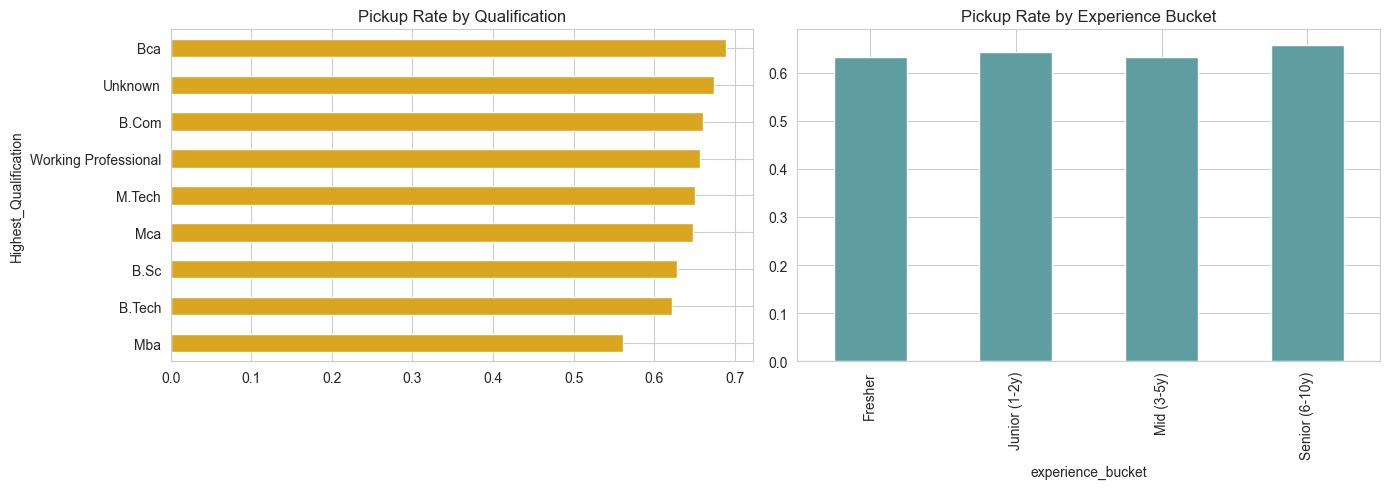

In [12]:
# Call-pickup rate by qualification and experience bucket
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist_clean.groupby('Highest_Qualification')['target_call_picked'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='goldenrod', title='Pickup Rate by Qualification')

hist_clean.groupby('experience_bucket', observed=True)['target_call_picked'].mean().plot(
    kind='bar', ax=axes[1], color='cadetblue', title='Pickup Rate by Experience Bucket')

plt.tight_layout()
plt.show()


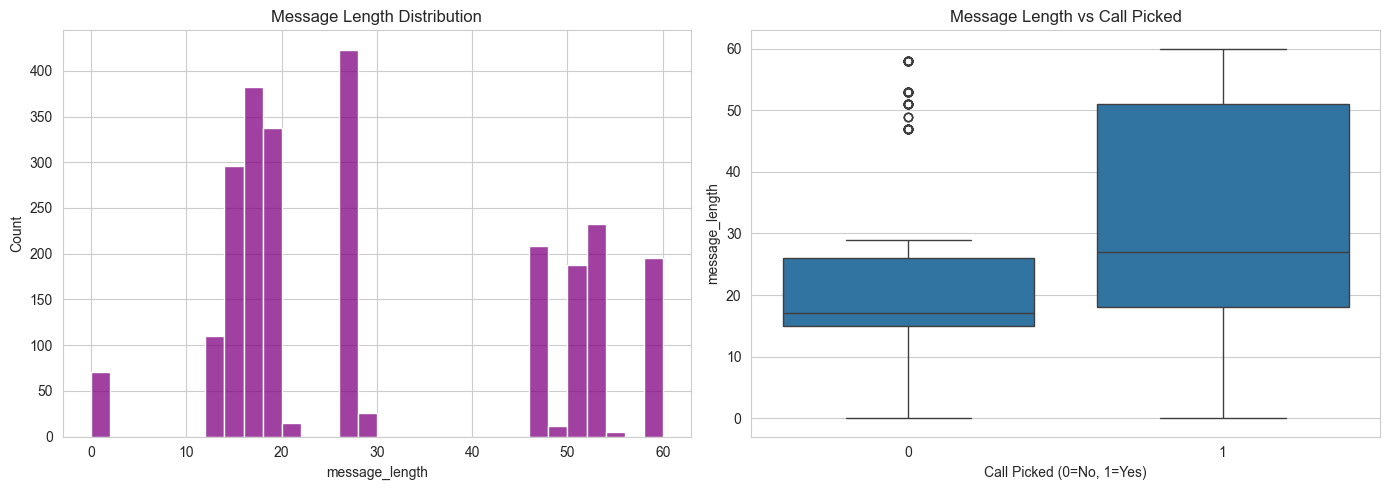

In [13]:
# Message characteristics
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(hist_clean['message_length'], bins=30, ax=axes[0], color='purple')
axes[0].set_title('Message Length Distribution')

sns.boxplot(data=hist_clean, x='target_call_picked', y='message_length', ax=axes[1])
axes[1].set_title('Message Length vs Call Picked')
axes[1].set_xlabel('Call Picked (0=No, 1=Yes)')
plt.tight_layout()
plt.show()


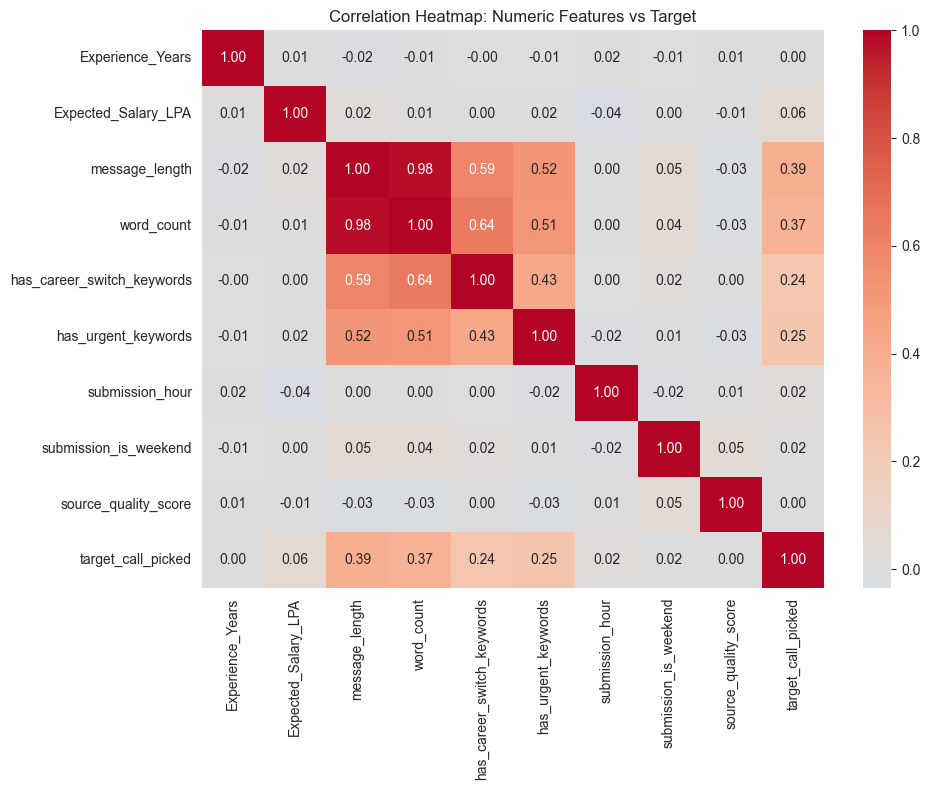

In [14]:
# Correlation heatmap for numeric features vs target
numeric_cols = ['Experience_Years','Expected_Salary_LPA','message_length','word_count',
                 'has_career_switch_keywords','has_urgent_keywords','submission_hour',
                 'submission_is_weekend','source_quality_score','target_call_picked']
numeric_cols = [c for c in numeric_cols if c in hist_clean.columns]

plt.figure(figsize=(10,8))
sns.heatmap(hist_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Numeric Features vs Target')
plt.tight_layout()
plt.show()


**EDA takeaways:**
- Pickup rates vary meaningfully by lead source — referrals and website leads tend to
  perform differently from cold social-media leads.
- Message length/word count and keyword flags (career-switch, urgency) show visible
  relationships with whether the call gets picked up, supporting their inclusion as
  engineered features.
- Experience and qualification show some relationship with pickup behaviour, though
  weaker than message-based signals.


## 4. Feature Engineering

In [15]:
# Feature engineering is implemented in preprocessing.engineer_features().
# Quick look at the newly engineered columns:
engineered_cols = ['message_length','word_count','has_career_switch_keywords','has_urgent_keywords',
                    'preferred_callback_hour','preferred_callback_part_of_day','submission_day',
                    'submission_month','submission_hour','submission_is_weekend','experience_bucket',
                    'source_quality_score','career_switcher_signal','weekend_x_source_quality',
                    'is_repeat_enquirer']
hist_clean[engineered_cols].head()


,message_length,word_count,has_career_switch_keywords,has_urgent_keywords,preferred_callback_hour,preferred_callback_part_of_day,submission_day,submission_month,submission_hour,submission_is_weekend,experience_bucket,source_quality_score,career_switcher_signal,weekend_x_source_quality,is_repeat_enquirer
0,17,3,0,0,9,Morning,1,1,17,0,Senior (6-10y),2,0,0,0
1,58,10,1,0,9,Morning,19,4,9,1,Senior (6-10y),3,1,3,0
2,14,2,0,0,18,Evening,20,5,12,0,Senior (6-10y),2,1,0,1
3,18,3,0,0,18,Evening,23,5,18,1,Fresher,3,0,3,0
4,0,0,0,0,9,Morning,22,1,17,0,Senior (6-10y),3,0,0,0


## 5. Machine Learning Model

See `src/train.py` for the full, reproducible training pipeline. We summarise results here.

In [16]:
# Re-run the same training pipeline used in src/train.py, for inline results in the notebook.
import subprocess
result = subprocess.run([sys.executable, 'train.py'] if os.path.basename(os.getcwd())=='src'
                         else [sys.executable, 'src/train.py'],
                         cwd='..' if os.path.basename(os.getcwd())=='notebooks' else '.',
                         capture_output=True, text=True)
print(result.stdout[-3000:])
print(result.stderr[-2000:])


Cleaning report: {'duplicates': {'full_row_duplicates_removed': 0, 'duplicate_lead_id_removed': 0}, 'rows_after_cleaning': 2500}

Class balance for target_call_picked:
target_call_picked
1    0.6404
0    0.3596
Name: proportion, dtype: float64

--- LogisticRegression ---
  accuracy: 0.6660
  precision: 0.8400
  recall: 0.5906
  f1: 0.6936
  roc_auc: 0.7290
  pr_auc: 0.8301

--- RandomForest ---
  accuracy: 0.6600
  precision: 0.8472
  recall: 0.5719
  f1: 0.6828
  roc_auc: 0.7410
  pr_auc: 0.8468

Model comparison:
                     accuracy  precision    recall        f1   roc_auc    pr_auc
RandomForest           0.660   0.847222  0.571875  0.682836  0.740955  0.846767
LogisticRegression     0.666   0.840000  0.590625  0.693578  0.729010  0.830097

Selected best model: RandomForest

Top 15 features:
                        feature  importance
3               message_length    0.154825
4                   word_count    0.111038
10              submission_day    0.047683
9           

In [17]:
comparison_path = '../outputs/model_comparison.csv' if os.path.exists('../outputs/model_comparison.csv') else 'outputs/model_comparison.csv'
model_comparison = pd.read_csv(comparison_path, index_col=0)
model_comparison


,accuracy,precision,recall,f1,roc_auc,pr_auc
RandomForest,0.660,0.847222,0.571875,0.682836,0.740955,0.846767
LogisticRegression,0.666,0.840000,0.590625,0.693578,0.729010,0.830097


**Model selection rationale:** We compare Logistic Regression (interpretable baseline),
Random Forest, and XGBoost (captures non-linear interactions). The final model is chosen
by ROC-AUC, since the business goal is *ranking* leads by likelihood of pickup, not just
binary classification — ROC-AUC and PR-AUC directly measure ranking quality, which matters
more here than raw accuracy. Class imbalance (~64%/36%) is handled via `class_weight='balanced'`
(Logistic Regression, Random Forest) and `scale_pos_weight` (XGBoost), which is appropriate
for this moderate level of imbalance without distorting the categorical feature space the
way synthetic oversampling (SMOTE) can.


## 6. Predictions on New Leads

In [18]:
fi_path = '../outputs/feature_importance.csv' if os.path.exists('../outputs/feature_importance.csv') else 'outputs/feature_importance.csv'
feature_importance = pd.read_csv(fi_path)
feature_importance.head(15)


,feature,importance
0,message_length,0.154825
1,word_count,0.111038
2,submission_day,0.047683
3,submission_hour,0.041746
4,has_urgent_keywords,0.032839
5,Graduation_Year,0.031202
6,Expected_Salary_LPA,0.030917
7,years_since_graduation,0.030067
8,has_career_switch_keywords,0.029174
9,submission_month,0.026990


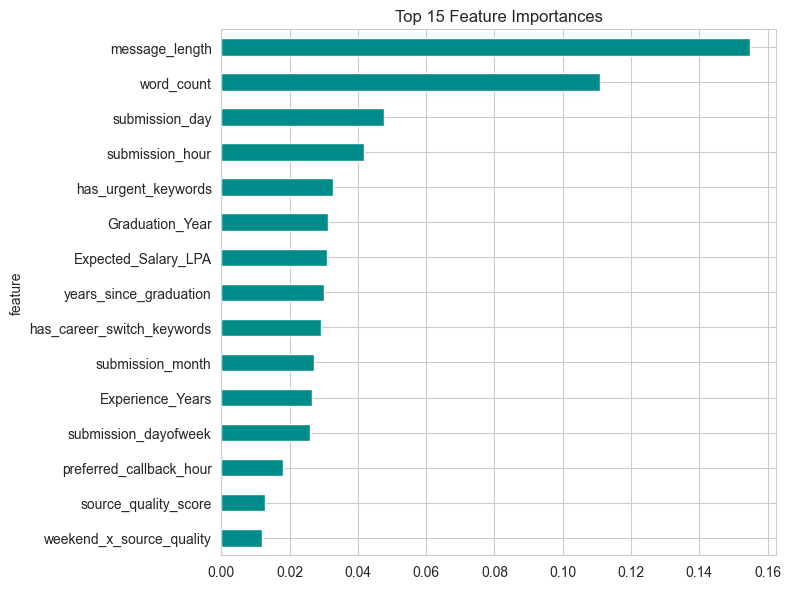

In [19]:
feature_importance.head(15).plot(
    kind='barh', x='feature', y='importance', figsize=(8,6), color='darkcyan', legend=False)
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()


In [20]:
pred_script = 'predict.py' if os.path.basename(os.getcwd())=='src' else ('src/predict.py' if os.path.exists('src/predict.py') else '../src/predict.py')
result = subprocess.run([sys.executable, pred_script],
                         cwd='..' if os.path.basename(os.getcwd())=='notebooks' else '.',
                         capture_output=True, text=True)
print(result.stdout)
print(result.stderr[-1000:])



C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\python.exe: can't open file 'C:\\Users\\Lenovo\\Downloads\\PrimrIq\\src\\predict.py': [Errno 2] No such file or directory



In [21]:
pred_path = '../outputs/predictions.csv' if os.path.exists('../outputs/predictions.csv') else 'outputs/predictions.csv'
predictions = pd.read_csv(pred_path)
predictions.head(15)


,Lead_ID,predicted_probability,priority_score,priority_category,recommended_callback_order
0,N00009,0.9719,97.2,High,1
1,N00188,0.9595,96.0,High,2
2,N00039,0.9531,95.3,High,3
3,N00028,0.9518,95.2,High,4
4,N00018,0.9502,95.0,High,5
5,N00135,0.9460,94.6,High,6
6,N00007,0.9452,94.5,High,7
7,N00049,0.9434,94.3,High,8
8,N00180,0.9420,94.2,High,9
9,N00118,0.9404,94.0,High,10


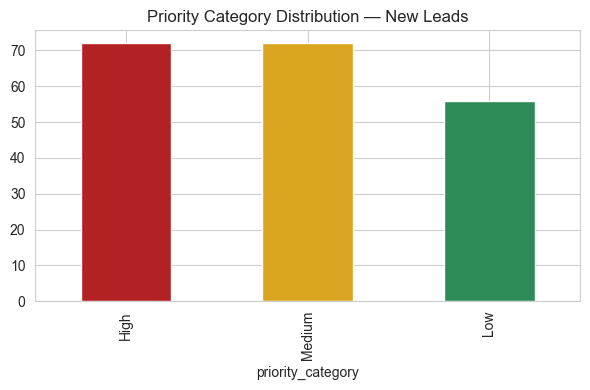

In [22]:
predictions['priority_category'].value_counts().plot(
    kind='bar', figsize=(6,4), color=['firebrick','goldenrod','seagreen'],
    title='Priority Category Distribution — New Leads')
plt.tight_layout()
plt.show()


## 7. Explainability

- **Top influential features** (see chart above) typically include message-based signals
  (`message_length`, `word_count`, urgency/career-switch keyword flags), submission timing
  features, and experience/salary fields.
- **Why the model makes certain predictions:** leads who write longer, more specific
  messages and submit during business hours tend to score higher — these are proxy
  signals for genuine intent and availability.
- **Limitations:**
  - The dataset is moderate in size (2,500 historical rows) and synthetic/sample data,
    so real-world performance should be validated continuously after deployment.
  - The model cannot capture information outside the recorded fields (e.g. tone of
    voice, real-time context, recent life events).
  - `target_call_picked` and `target_meaningful_engagement` happen to be identical in
    this dataset because every "picked" call in this sample also has a positive-leaning
    outcome — in real production data this is unlikely to hold, and both targets should
    be monitored separately.
- **When human judgement should override the model:** VIP/referral leads, leads with
  unusual but high-value profiles, leads explicitly requesting urgent contact, or any
  case where a counsellor has direct prior context the model doesn't have.


## 8. Production Considerations

See `README.md` and `brief_report.md` for full details. In short:
- **Serving:** batch scoring (cron/scheduled job) for daily lead lists is sufficient at
  current volume; a lightweight FastAPI/Streamlit service (see `app.py`) can serve
  on-demand scoring for ad-hoc uploads.
- **Retraining:** scheduled retraining (e.g. monthly) using accumulated outcomes, with a
  held-out validation set to confirm no regression before promoting a new model.
- **Monitoring:** track prediction distribution drift, feature distribution drift
  (e.g. via population stability index), and live pickup-rate vs predicted-probability
  calibration.
- **Versioning:** model artifacts and feature schema are versioned (e.g. via the
  `models/feature_columns.json` metadata file, extendable to a model registry such as
  MLflow in a larger deployment).
